# Fibers: Advanced

In this example a composite section is built by joining multiple basic shapes.

In [1]:
from xsection import CompositeSection
from xara.units.iks import inch, foot, ksi, kip 
import matplotlib.pyplot as plt
import numpy as np
import veux

In [2]:
from xara import UniaxialMaterial, Section

# Define materials
materials = {
    "core": UniaxialMaterial(
        type = "Concrete02",
        Fc  =   7.08*ksi,
        nu  =  0.2,
        ec0 =  0.00295,
        Fcu =  5*ksi,
        ecu =  0.014
    ),
    "cover": UniaxialMaterial(
        type = "Concrete02",
        Fc  =   -6.5*ksi,
        nu  =   0.2,
        ec0 =  -0.002,
        Fcu =  -0.5*ksi,
        ecu =  -0.005,
        # "lambda": 0.1,
        # "Ft": 0.65*ksi,
        # "Ets": 500. # Tension stiffening
    ),
    "rebar": UniaxialMaterial(
        type = "Steel01",
        nu = 0.3,
        E  =   29e3*ksi,
        Fy =     40*ksi,
        b =   0.05
    )
}

## Rectangle

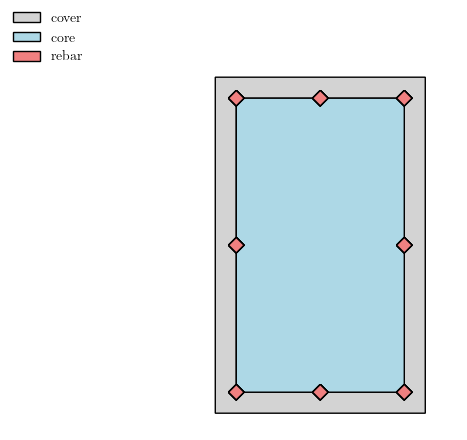

In [4]:
from xsection.library import Rectangle, Circle, HollowRectangle
from xsection import CompositeSection

h = 24
b = 15
d = 7/8
r = 0 #d/2

c = 1.5

bar = Circle(d/2, z=2, 
             material=materials["rebar"],
             mesh_scale=1/2, divisions=4, group="rebar")

cover = HollowRectangle(b, h, t=c, z=0, 
                        group="cover", 
                        material=materials["cover"]
)

core = Rectangle(b-2*c, h-2*c, z=1, 
                 group="core", material=materials["core"])

shape = CompositeSection([
            cover,
            core,
            *bar.linspace([-b/2+c+r, -h/2+c+r], [ b/2-c-r,-h/2+c+r], 3), # Top bars
            *bar.linspace([-b/2+c+r,        0], [ b/2-c-r,       0], 2), # Center bars
            *bar.linspace([-b/2+c+r,  h/2-c-r], [ b/2-c-r, h/2-c-r], 3)  # Bottom bars
        ])



veux.draw_shape(shape)

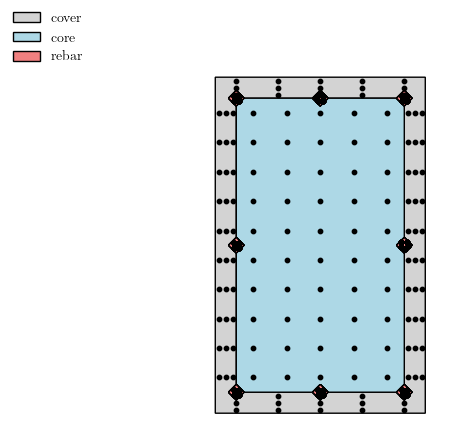

In [5]:
fibers = {
    "cover": {"d": 10, "t": 3, "b": 5},
    "core":  {"d": 10, "b": 5},
}

import xara 

section = xara.Section("Fiber", shape, fibers=fibers)

veux.draw_shape(section)